# **Importing Importing Libraries**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD

# **Loading Dataset**

In [47]:
train_image = 'C:/Users/123/OneDrive - hull.ac.uk/understand ai salah/Project_folder/train/images'
train_labels = 'C:/Users/123/OneDrive - hull.ac.uk/understand ai salah/Project_folder/train/train.csv'

test_image = 'C:/Users/123/OneDrive - hull.ac.uk/understand ai salah/Project_folder/test/images'
test_labels = 'C:/Users/123/OneDrive - hull.ac.uk/understand ai salah/Project_folder/test/test.csv'

## Inspecting Training and Test csv

In [50]:
# Loading the training labels CSV to inspect its structure
train_labels = pd.read_csv('C:/Users/123/OneDrive - hull.ac.uk/understand ai salah/Project_folder/train/train.csv')

# Displaying the first few rows of the DataFrame
print(train_labels.head(20))

# Displaying the column names
print(train_labels.columns)


    image_id filename  label
0          1    1.jpg      2
1          2    2.jpg      4
2          3    3.jpg      2
3          4    4.jpg      3
4          5    5.jpg      5
5          6    6.jpg      2
6          7    7.jpg      5
7          8    8.jpg      5
8          9    9.jpg      5
9         10   10.jpg      5
10        11   11.jpg      2
11        12   12.jpg      6
12        13   13.jpg      6
13        14   14.jpg      4
14        15   15.jpg      6
15        16   16.jpg      4
16        17   17.jpg      2
17        18   18.jpg      6
18        19   19.jpg      5
19        20   20.jpg      4
Index(['image_id', 'filename', 'label'], dtype='object')


In [54]:
# Loading the test labels CSV to inspect its structure
test_labels = pd.read_csv('C:/Users/123/OneDrive - hull.ac.uk/understand ai salah/Project_folder/test/test.csv')

# Displaying the first few rows of the DataFrame
print(test_labels.head(10))

# Displaying the column names
print(test_labels.columns)

   image_id  filename
0      7201  7201.jpg
1      7202  7202.jpg
2      7203  7203.jpg
3      7204  7204.jpg
4      7205  7205.jpg
5      7206  7206.jpg
6      7207  7207.jpg
7      7208  7208.jpg
8      7209  7209.jpg
9      7210  7210.jpg
Index(['image_id', 'filename'], dtype='object')


In [58]:
# Checking what files are actually in my image directory
image_files = os.listdir("C:/Users/123/OneDrive - hull.ac.uk/understand ai salah/Project_folder/train/images")
print("First 5 files in images directory:", image_files[:5])

# Checking what filenames are in my CSV
print("First 5 filenames in CSV:", train_labels['filename'].head())

First 5 files in images directory: ['1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg']
First 5 filenames in CSV: 0    1.jpg
1    2.jpg
2    3.jpg
3    4.jpg
4    5.jpg
Name: filename, dtype: object


# **Preprocessing Trainning Data**

Image 1.jpg (Label: 2 - scratch) - Shape: (1080, 1440, 3), Min: 0, Max: 255
Image 10.jpg (Label: 5 - window broken) - Shape: (1044, 1392, 3), Min: 0, Max: 252
Image 100.jpg (Label: 6 - lamp broken) - Shape: (891, 1188, 3), Min: 0, Max: 205
Image 1000.jpg (Label: 2 - scratch) - Shape: (996, 1329, 3), Min: 0, Max: 255
Image 1001.jpg (Label: 4 - dent) - Shape: (884, 1179, 3), Min: 0, Max: 255
Image 1002.jpg (Label: 4 - dent) - Shape: (642, 856, 3), Min: 0, Max: 255
Image 1003.jpg (Label: 6 - lamp broken) - Shape: (1011, 1348, 3), Min: 0, Max: 232
Image 1004.jpg (Label: 2 - scratch) - Shape: (870, 1161, 3), Min: 0, Max: 255
Image 1005.jpg (Label: 4 - dent) - Shape: (1098, 1464, 3), Min: 0, Max: 255
Image 1006.jpg (Label: 2 - scratch) - Shape: (825, 1101, 3), Min: 0, Max: 255


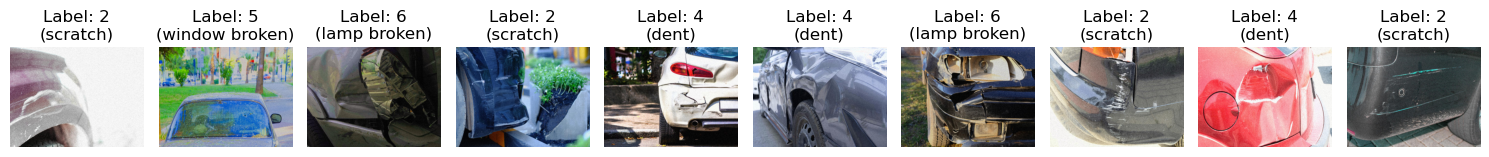


Label to Class Mapping:
2: scratch
4: dent
3: flat tire
5: window broken
6: lamp broken


In [66]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Definning paths
base_image_dir = "project_folder/train/images"
train_csv_path = "project_folder/train/train.csv"

# Definning the label to class name mapping
elements = {
    2: "scratch",
    4: "dent",
    3: "flat tire",
    5: "window broken",
    6: "lamp broken"
}

train_labels_df = pd.read_csv(train_csv_path)

# list of image files (first 10)
image_files = sorted([f for f in os.listdir(base_image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])[:10]

# Plotting first 10 images with labels 
fig, axs = plt.subplots(1, 10, figsize=(15, 3))
for i, img_file in enumerate(image_files):
    img_path = os.path.join(base_image_dir, img_file)
    img = plt.imread(img_path)
    axs[i].imshow(img)

    # Getting label from DataFrame (matching filename)
    label = train_labels_df[train_labels_df['filename'] == img_file]['label'].values[0]

    # Getting the class name from our mapping
    class_name = elements.get(label, "unknown")

    axs[i].set_title(f"Label: {label}\n({class_name})")
    axs[i].axis('off')

    # Now printing image array info with class name
    print(f"Image {img_file} (Label: {label} - {class_name}) - Shape: {img.shape}, Min: {img.min()}, Max: {img.max()}")

plt.tight_layout()
plt.show()

# Printting the complete mapping
print("\nLabel to Class Mapping:")
for label_num, class_name in elements.items():
    print(f"{label_num}: {class_name}")

Train Image 1.jpg (Label: 2 - scratch) - Shape: (1080, 1440, 3)
Train Image 10.jpg (Label: 5 - window broken) - Shape: (1044, 1392, 3)
Train Image 100.jpg (Label: 6 - lamp broken) - Shape: (891, 1188, 3)
Train Image 1000.jpg (Label: 2 - scratch) - Shape: (996, 1329, 3)
Train Image 1001.jpg (Label: 4 - dent) - Shape: (884, 1179, 3)
Test Image 10000.jpg - Shape: (907, 1210, 3)
Test Image 10001.jpg - Shape: (998, 1331, 3)
Test Image 10002.jpg - Shape: (625, 834, 3)
Test Image 10003.jpg - Shape: (927, 1237, 3)
Test Image 10004.jpg - Shape: (617, 823, 3)


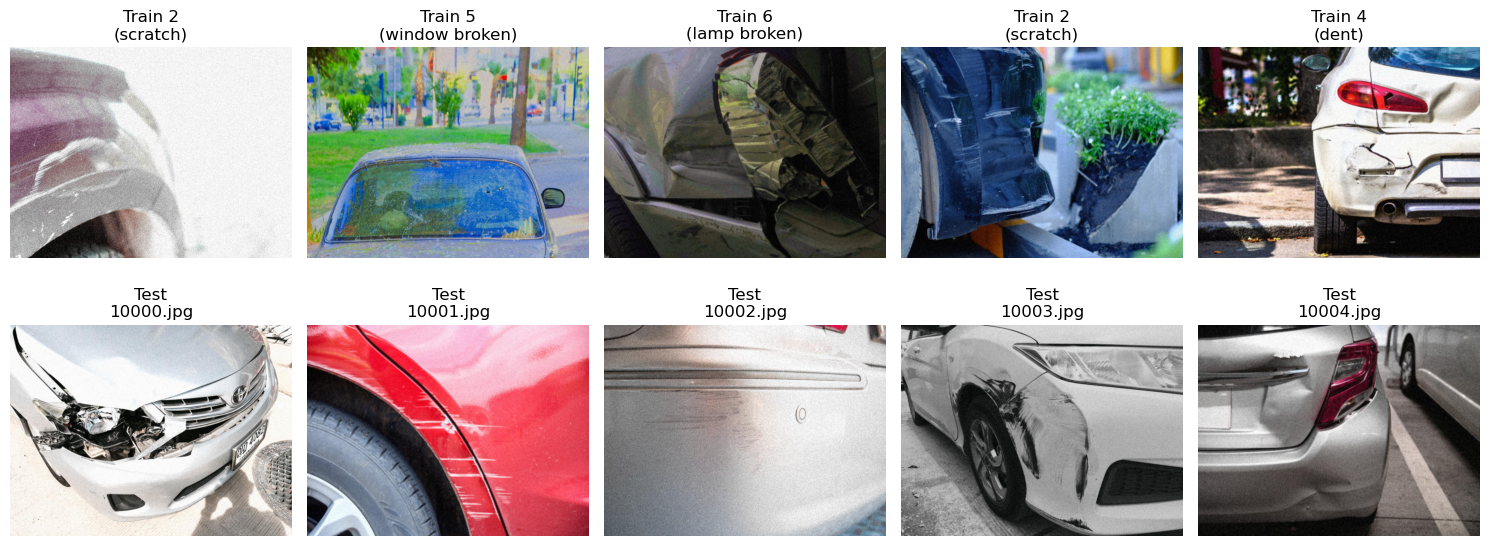


Label to Class Mapping:
2: scratch
4: dent
3: flat tire
5: window broken
6: lamp broken


In [74]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Define paths
train_image_dir = "project_folder/train/images"
train_labels_path = "project_folder/train/train.csv"
test_image_dir = "project_folder/test/images"

# Define the label to class name mapping
element = {
    2: "scratch",
    4: "dent",
    3: "flat tire",
    5: "window broken",
    6: "lamp broken"
}

# Loading the training labels
train_labels_df = pd.read_csv(train_labels_path)

# Getting list of image
train_images = sorted([f for f in os.listdir(train_image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])[:5]
test_images = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])[:5]

# Now Creating figure with 2 rows (train and test) and 5 columns
fig, axs = plt.subplots(2, 5, figsize=(15, 6))

# Plotting training images (first row)
for i, img_file in enumerate(train_images):
    img_path = os.path.join(train_image_dir, img_file)
    x_img = plt.imread(img_path)
    axs[0, i].imshow(x_img)

    label = train_labels_df[train_labels_df['filename'] == img_file]['label'].values[0]
    class_name = element.get(label, "unknown")

    axs[0, i].set_title(f"Train {label}\n({class_name})")
    axs[0, i].axis('off')

    print(f"Train Image {img_file} (Label: {label} - {class_name}) - Shape: {x_img.shape}")

# Plotting test images (second row)
for i, img_file in enumerate(test_images):
    img_path = os.path.join(test_image_dir, img_file)
    y_img = plt.imread(img_path)
    axs[1, i].imshow(y_img)

    # Testing images only have filenames, no labels
    axs[1, i].set_title(f"Test\n{img_file}")
    axs[1, i].axis('off')

    print(f"Test Image {img_file} - Shape: {y_img.shape}")

plt.tight_layout()
plt.show()

# Printing the complete mapping for reference
print("\nLabel to Class Mapping:")
for label_num, class_name in element.items():
    print(f"{label_num}: {class_name}")

In [76]:
# This shows the shape of one train image ( lenght, width)
x_img[1].shape

(1179, 3)

In [78]:
x_img

array([[[ 30,  44,  47],
        [ 26,  40,  41],
        [ 22,  36,  37],
        ...,
        [ 81, 136, 167],
        [ 85, 140, 171],
        [ 89, 144, 175]],

       [[ 30,  44,  47],
        [ 27,  41,  44],
        [ 23,  37,  38],
        ...,
        [ 79, 133, 167],
        [ 82, 138, 171],
        [ 86, 142, 175]],

       [[ 30,  44,  47],
        [ 28,  42,  45],
        [ 24,  38,  41],
        ...,
        [ 76, 132, 165],
        [ 79, 135, 168],
        [ 81, 140, 172]],

       ...,

       [[ 78,  77,  93],
        [ 75,  74,  90],
        [ 68,  70,  85],
        ...,
        [ 83,  67,  67],
        [ 76,  58,  58],
        [ 70,  51,  53]],

       [[ 75,  74,  90],
        [ 72,  71,  87],
        [ 65,  67,  82],
        ...,
        [ 91,  75,  75],
        [ 84,  66,  66],
        [ 78,  59,  61]],

       [[ 72,  71,  87],
        [ 69,  68,  84],
        [ 63,  65,  80],
        ...,
        [ 93,  77,  77],
        [ 86,  68,  68],
        [ 80,  61,  63]]

In [80]:
y_img[1].shape

(823, 3)

In [82]:
x_img = img /255.0
y_img = img /255.0


In [84]:
x_img


array([[[0.21960784, 0.22352941, 0.20392157],
        [0.19215686, 0.19607843, 0.17647059],
        [0.20784314, 0.21176471, 0.19215686],
        ...,
        [0.18431373, 0.21568627, 0.22352941],
        [0.16862745, 0.2       , 0.20784314],
        [0.17647059, 0.20784314, 0.21568627]],

       [[0.25490196, 0.25490196, 0.24705882],
        [0.30588235, 0.30588235, 0.29803922],
        [0.31764706, 0.31764706, 0.30980392],
        ...,
        [0.14117647, 0.17254902, 0.18039216],
        [0.12156863, 0.15294118, 0.16078431],
        [0.14901961, 0.18039216, 0.18823529]],

       [[0.14901961, 0.14901961, 0.14117647],
        [0.22352941, 0.22352941, 0.21568627],
        [0.27058824, 0.27058824, 0.2627451 ],
        ...,
        [0.14509804, 0.17647059, 0.18431373],
        [0.11372549, 0.14509804, 0.15294118],
        [0.14901961, 0.18039216, 0.18823529]],

       ...,

       [[0.50980392, 0.47843137, 0.46666667],
        [0.45490196, 0.42352941, 0.41176471],
        [0.4       , 0

# Image transformations for data augmentation

In [90]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [94]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
 rotation_range=20, 
 width_shift_range=0.1, 
 height_shift_range=0.1, 
 horizontal_flip=True, 
 vertical_flip=False, 
 shear_range=0.10, 
 zoom_range=0.10 
 )

In [96]:
import numpy as np
import os
from PIL import Image

# 1. Creating a list to hold your training images
train_images = []

# 2. Looping through the images in your training directory and loading them
for filename in os.listdir(train_image_dir):
    if filename.endswith(".jpg") or filename.endswith(".png"):  
        img_path = os.path.join(train_image_dir, filename)
        img = Image.open(img_path).convert('RGB')  
        img = img.resize((224, 224))
        img_array = np.array(img) / 255.0
        train_images.append(img_array)

# 3. Converting the list of images to a NumPy array
train_images = np.array(train_images, dtype=np.float32)

# 4. Now I can fit the ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.10,
    zoom_range=0.10
)
train_datagen.fit(train_images)

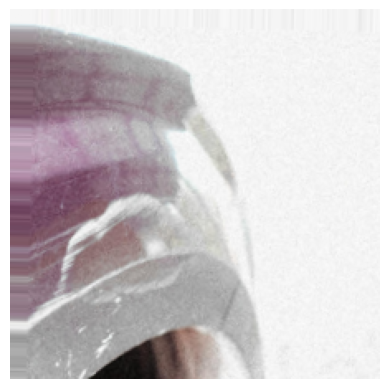

In [97]:
# applying the random transformation to the first image
new_image = train_datagen.random_transform(train_images[0])

#using matplotlib to show this image
plt.imshow(new_image, cmap='gray')
plt.gca().axis('off')
plt.show()

In [102]:
import numpy as np
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# Function to load and prepare images
def load_images(image_dir, image_files, labels_df=None):
    images = []
    labels = []

    for img_file in image_files:
        img_path = os.path.join(image_dir, img_file)
        img = plt.imread(img_path)

        if img.shape != (224, 224, 3):
            img = tf.image.resize(img, (224, 224))

        images.append(img)

        if labels_df is not None:
            label = labels_df[labels_df['filename'] == img_file]['label'].values[0]
            labels.append(label)

    images = np.array(images) / 255.0  # Normalizing to [0,1]

    if labels_df is not None:
        labels = to_categorical(np.array(labels) - 2) 
        return images, labels
    else:
        return images

# Loading all training images and labels
train_image_files = [f for f in os.listdir(train_image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
x_train, y_train = load_images(train_image_dir, train_image_files, train_labels_df)

# Loading test images (no labels)
test_image_files = [f for f in os.listdir(test_image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
x_test = load_images(test_image_dir, test_image_files)

# **Defining CNN Model and Compiling The Model**

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

In [6]:
model = Sequential()
model.add(Input(shape=(224, 224, 3)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 110, 110, 128)       │          36,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 55, 55, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 53, 53, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,338,181 (85.21 MB)

 Trainable params: 22,338,181 (85.21 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:
from tensorflow.keras.optimizers import SGD

model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

## Splitting Data into Traning and Validation


In [115]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Create data generator with augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

## Training The Defined Model

In [118]:
history = model.fit(
    train_datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_val, y_val),
    steps_per_epoch=len(x_train) // 32
)

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.3153 - loss: 1.5111 - val_accuracy: 0.3524 - val_loss: 1.3960
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.3745 - loss: 1.4066 - val_accuracy: 0.4219 - val_loss: 1.3232
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.4017 - loss: 1.3321 - val_accuracy: 0.4392 - val_loss: 1.2339
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.4219 - loss: 1.3129 - val_accuracy: 0.4427 - val_loss: 1.2411
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.4411 - loss: 1.2826 - val_accuracy: 0.4740 - val_loss: 1.1879
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.4505 - loss: 1.2284 - val_accuracy: 0.4479 - val_loss: 1.2165
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.4660 - loss: 1.2109 - val_accuracy: 0.4974 - val_loss: 1.0904
Epoch 8/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.4829 - loss: 1.1290 - val_accu

## Ploting The Training And Validation Accuracy

In [127]:
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

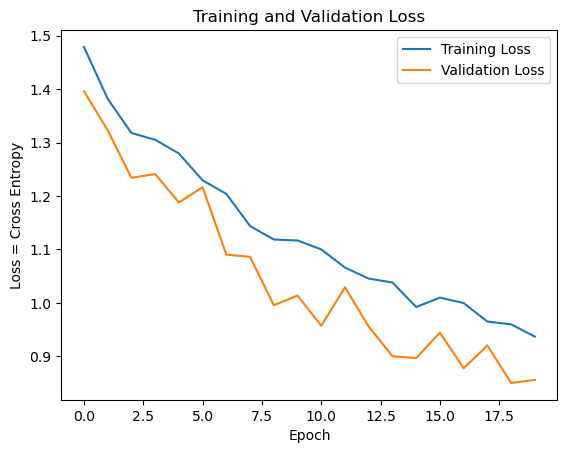

In [129]:
# checking for overfitting
 # Plot training loss against validation loss
 #Plots the training loss as a line with label "Training Loss".
plt.plot(history.history['loss'], label='Training Loss')
 #Plots the validation loss as a line with label "Validation Loss".
plt.plot(history.history['val_loss'], label='Validation Loss')
 #Sets the title of the plot to "Training and Validation Loss".
plt.title('Training and Validation Loss')
 #Sets the label of the x-axis to "Epochs".
plt.xlabel('Epoch')
 #Sets the label of the y-axis to "Loss".
plt.ylabel('Loss = Cross Entropy')
 #Shows the legend of the plot with the labels of the two lines.
plt.legend()
 #Shows the plot on the screen.
plt.show()

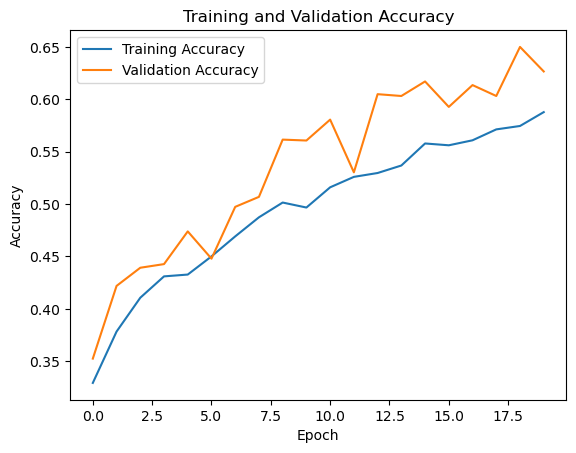

In [124]:
# Plot training and validation accuracy
 #Plots the training accuracy as a line with label "Training Accuracy".
plt.plot(history.history['accuracy'], label='Training Accuracy')
 #Plots the validation accuracy as a line with label "Validation Accuracy".
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
 #Sets the title of the plot to "Training and Validation Accuracy".
plt.title('Training and Validation Accuracy')
#Sets the label of the x-axis to "Epochs".
plt.xlabel('Epoch')
 #Sets the label of the y-axis to "Accuracy".
plt.ylabel('Accuracy')
#Shows the legend of the plot with the labels of the two lines.
plt.legend()
 #Shows the plot on the screen.
plt.show()

### Predict the classes of the test set

In [132]:

val_pred = np.argmax(model.predict(x_val), axis=-1)


36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step


# Visual Results

In [134]:
# Converting one-hot encoded y_val to class indices
y_val_labels = np.argmax(y_val, axis=1)

# val_pred is already in class indices format
from sklearn.metrics import classification_report

# Define your class names in order (0-4)
class_names = ["scratch", "flat tire", "dent", "window broken", "lamp broken"]

print(classification_report(
    y_val_labels, 
    val_pred,
    target_names=class_names
))


# 1. Geting predictions 
val_pred = np.argmax(model.predict(x_val), axis=-1)

# 2. Converting y_val from one-hot to class indices
y_val_labels = np.argmax(y_val, axis=1)

# 3. Verifying shapes
print(f"y_val shape: {y_val.shape}")  # Should be (n_samples, n_classes)
print(f"val_pred shape: {val_pred.shape}")  # Should be (n_samples,)

# 4. Generating report
print("\nClassification Report:")
print(classification_report(
    y_val_labels,
    val_pred,
    target_names=class_names,
    digits=4
))

# Check unique values in predictions
print("\nUnique predicted classes:", np.unique(val_pred))
print("Unique true classes:", np.unique(y_val_labels))

for i in range(5):
    print(f"\nSample {i}:")
    print(f"True: {class_names[y_val_labels[i]]} ({y_val_labels[i]})")
    print(f"Pred: {class_names[val_pred[i]]} ({val_pred[i]})")
    print(f"Confidence: {np.max(model.predict(x_val[i:i+1])):.2f}")

               precision    recall  f1-score   support

      scratch       0.60      0.67      0.63       384
    flat tire       0.87      0.74      0.80        70
         dent       0.56      0.45      0.50       340
window broken       0.69      0.95      0.80       189
  lamp broken       0.59      0.47      0.53       169

     accuracy                           0.63      1152
    macro avg       0.66      0.66      0.65      1152
 weighted avg       0.62      0.63      0.62      1152

36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step
y_val shape: (1152, 5)
val_pred shape: (1152,)

Classification Report:
               precision    recall  f1-score   support

      scratch     0.6019    0.6693    0.6338       384
    flat tire     0.8667    0.7429    0.8000        70
         dent     0.5646    0.4500    0.5008       340
window broken     0.6950    0.9524    0.8036       189
  lamp broken     0.5926    0.4734    0.5263       169

     accuracy                         0.6267      1152
   

<Figure size 2000x3000 with 0 Axes>

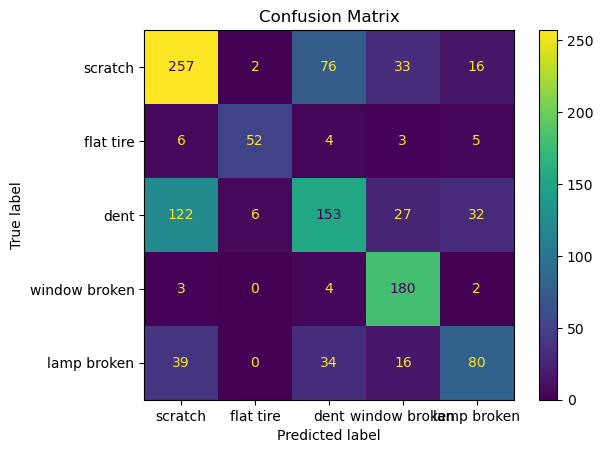

In [137]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(dpi=200, figsize=(10,15))
ConfusionMatrixDisplay.from_predictions(y_val_labels,val_pred, display_labels=class_names)
plt.title('Confusion Matrix')
plt.show()

# Accuracy, Precision, Recall, F1-Score Of The Model

In [140]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score



accuracy = accuracy_score(y_val_labels, val_pred)
precision = precision_score(y_val_labels, val_pred, average = 'weighted')
recall = recall_score(y_val_labels, val_pred, average = 'weighted')
f1 = f1_score (y_val_labels, val_pred, average = 'weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.6267
precision: 0.6209
recall: 0.6267
F1-Score: 0.6167
